In [33]:
import pandas as pd
import numpy as np
from numpy import mean
from numpy import std
import json

In [34]:
import sys
print(sys.executable)

/usr/local/bin/python3.10


Next you need to load a dataset file here

In [35]:
dataset_df = pd.read_csv('dataset.csv')
dataset_df.head()

,Temp0,Temp1,Temp2,Humi0,Humi1,Humi2,Snow
0,1.422137,1.272732,1.272732,0.247354,0.247354,0.247354,No
1,-0.221323,-0.221323,-0.221323,0.247354,0.391029,0.534704,No
2,-0.071917,-0.071917,-0.221323,0.822055,0.822055,0.822055,No
3,0.226894,0.376299,0.525705,0.606542,0.534704,-0.183672,No
4,-2.014189,-2.163594,-2.312999,0.103678,0.031841,-0.039997,No


First 6 columns are the data, next 1 is the label of "Yes" and "No" status of the snowfall. Total of 7 coulmns.

This dataset is *balanced*, meaning that there is an equal amount of "Yes" snow and "No" snow data. This is done to make the network less biased. If most of the data will be "Yes" (for example, 90%), then network will learn to say "Yes" all of the time and be correct 90% of the time.

*TASK:*
Z-score normalization (standardization) puts features on the same scale so they are easier for models to learn from. For each value, subtract the feature's average and divide by its standard deviation, so typical values end up near 0 with a spread of about ±1. This stops large-scale features from overpowering small ones and usually makes training faster and more stable.

Your task is to plot a graph of the dataset before Z-Score normalization and after.

*NOTE:* you can use seaborn and matplotlib


In [36]:
f_names = dataset_df.columns.values[0:6]
l_name = dataset_df.columns.values[6:7]
x = dataset_df[f_names]
y = dataset_df[l_name]

In [97]:
labelencoder = LabelEncoder()
labelencoder.fit(y.Snow)
y_encoded = labelencoder.transform(y.Snow)
print(dataset_df['Snow'].unique())
print(dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_))))

['No' 'Yes']
{'No': np.int64(0), 'Yes': np.int64(1)}


Data needs to be divided into a training, validation and testing sets.

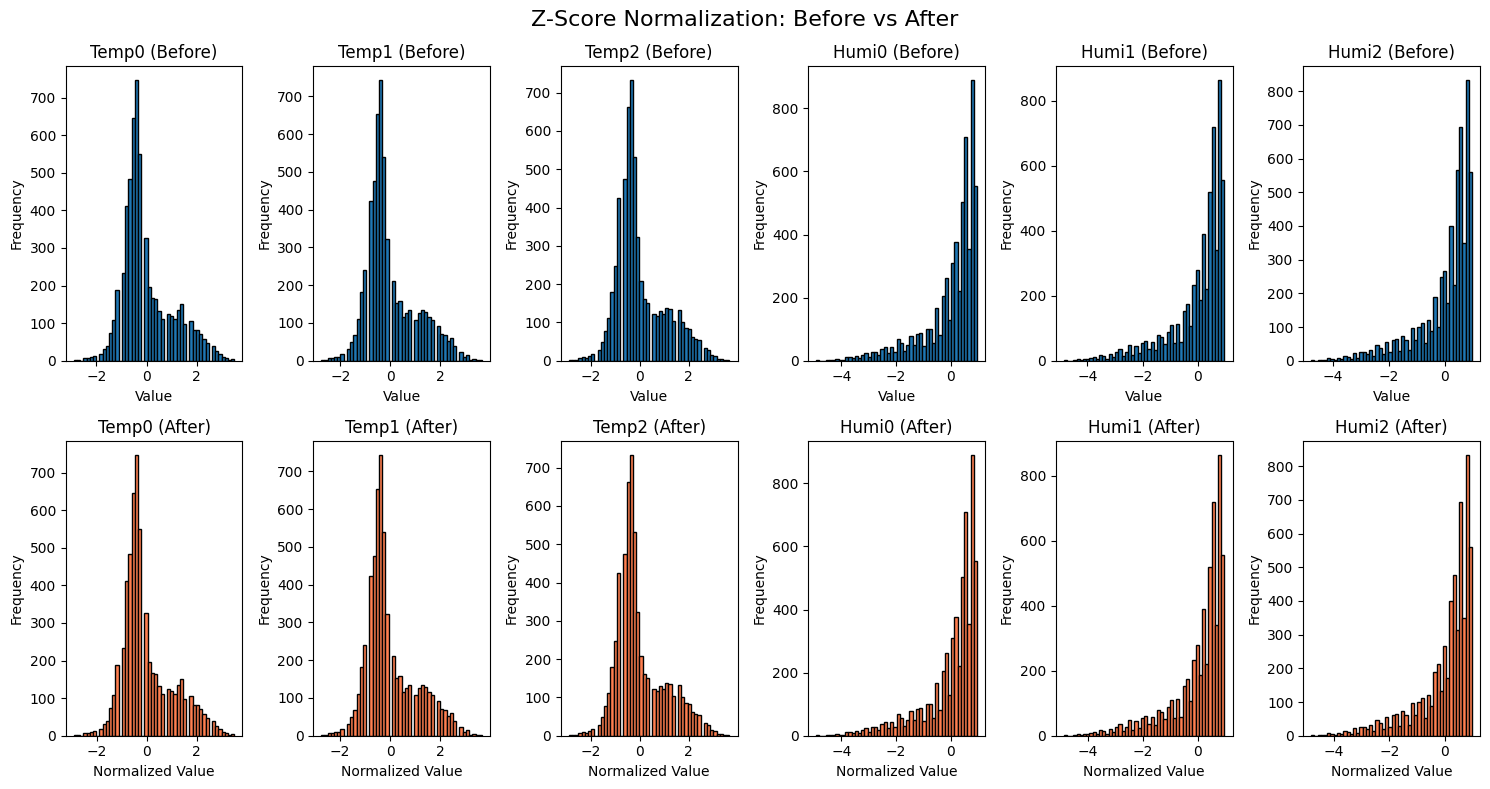

In [ ]:
# TASK 1: Z-Score Normalization. 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

#  original for comparison
x_before = x.copy()

# Normalization
scaler = StandardScaler()
x_normalized = scaler.fit_transform(x)
x_normalized = pd.DataFrame(x_normalized, columns=f_names)

# Plot
fig, axes = plt.subplots(2, 6, figsize=(15, 8))
fig.suptitle('Z-Score Normalization: Before vs After', fontsize=16)

for i, feature in enumerate(f_names):
    # Before
    axes[0, i].hist(x_before[feature], bins=50, edgecolor='black')
    axes[0, i].set_title(f'{feature} (Before)')
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Frequency')
    
    # After
    axes[1, i].hist(x_normalized[feature], bins=50, edgecolor='black', color='coral')
    axes[1, i].set_title(f'{feature} (After)')
    axes[1, i].set_xlabel('Normalized Value')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('z_score_normalization.png', dpi=150, bbox_inches='tight')
plt.show()

# Use normalized data for training
x = x_normalized

#we can see that data was already normalized

In [39]:
from sklearn.model_selection import train_test_split

# Split 1 (80% vs 20%)
x_train, x_validate_test, y_train, y_validate_test = train_test_split(x,
  y_encoded, test_size=0.20, random_state = 1)

# Split 2 (50% vs 50%)
x_test, x_validate, y_test, y_validate = train_test_split(x_validate_test,
  y_validate_test, test_size=0.50, random_state = 3)


Defining the architecture of our model. After you will finish the tasks, you can play around with the network to see if you can get better results. As of now, this is a minimal model that successfully does binary classification on snowfall status.

y = mx + b
m is like the weight (slope)
b is like the bias (y-intercept)

Input features: 6
Neurons: 12

Weights: 6 inputs × 12 neurons = 72 weights
Biases: 12 neurons = 12 biases
Total: 84 parameters

In [ ]:
#Build Neural Network

import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential()
model.add(layers.Dense(12, activation='relu',
  input_shape=(len(f_names),)))
model.add(layers.Dropout(0.2)) #Randomly disables 20% of neurons during training
model.add(layers.Dense(1, activation='sigmoid')) #outputs a probability between 0-1 for binary classification
model.summary()

#relu Allows network to learn non-linear relationships


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compile Model

model.compile(loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy'])

Here we train our model. We are doing it for 20 epochs with a batch size of 64. Epoch is passed when all of the training data is passed once through the training process, so 20 epochs mean that the data will pass 20 times through it.

Batch size is responsible for how many data points participate in the training at any given moment.

1.   During training:
If batch size = 32, the model sees 32 samples, averages their error, then updates its weights once.

2.   During inference:
If batch size = 8, you feed 8 inputs together and get 8 outputs in one go.

In [ ]:
#Set Parameters, Train Model

NUM_EPOCHS=20   # How many times to see ALL training data
BATCH_SIZE=64   # How many samples to process before updating

history = model.fit(x_train, y_train,
  epochs=NUM_EPOCHS,
  batch_size=BATCH_SIZE,
  validation_data=(x_validate,
  y_validate))

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7259 - loss: 0.5769 - val_accuracy: 0.8188 - val_loss: 0.4735
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - accuracy: 0.7841 - loss: 0.4766 - val_accuracy: 0.8255 - val_loss: 0.4136
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.8057 - loss: 0.4301 - val_accuracy: 0.8272 - val_loss: 0.3859
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - accuracy: 0.8139 - loss: 0.4083 - val_accuracy: 0.8356 - val_loss: 0.3706
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - accuracy: 0.8234 - loss: 0.3963 - val_accuracy: 0.8272 - val_loss: 0.3608
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.8311 - loss: 0.3855 - val_accuracy: 0.8339 - val_loss: 0.3534
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - accuracy: 0.8315 - loss: 0.3757 - val_accuracy: 0.8339 - val_loss: 0.3484
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - accuracy: 0.8284 - loss: 0.3722 - val_accuracy: 0.83

In [71]:
loss_train = history.history['loss']
loss_val= history.history['val_loss']
acc_train= history.history['accuracy']
acc_val= history.history['val_accuracy']
epochs= range(1, NUM_EPOCHS + 1)

here we get lists of:

1. Training Accuracy
2. Validation Accuracy
3. Training Loss
4. Validation Loss

*TASK:*

Plot the Training Accuracy & Validation Accuracy VS. Epochs graph.

Plot the Training Loss & Validation Loss VS. Epochs graph


*Note: you can use matplotlib*

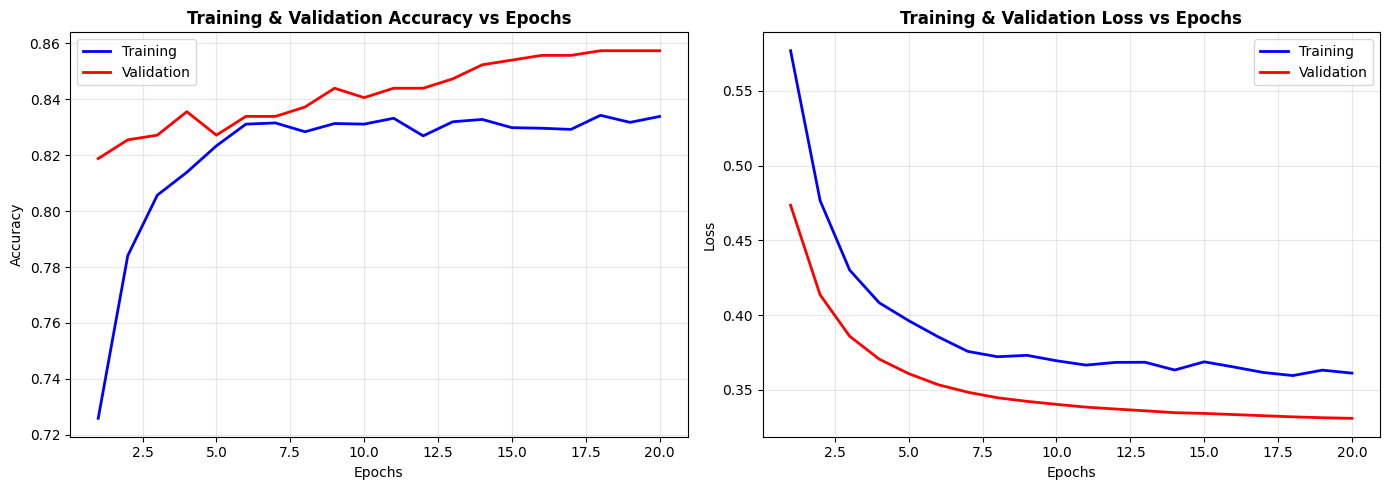

In [88]:
#Accuracy & Loss vs Epochs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs, acc_train, 'b-', label='Training', linewidth=2)
axes[0].plot(epochs, acc_val, 'r-', label='Validation', linewidth=2)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training & Validation Accuracy vs Epochs', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(epochs, loss_train, 'b-', label='Training', linewidth=2)
axes[1].plot(epochs, loss_val, 'r-', label='Validation', linewidth=2)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training & Validation Loss vs Epochs', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_loss_plots.png', dpi=150, bbox_inches='tight')
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step


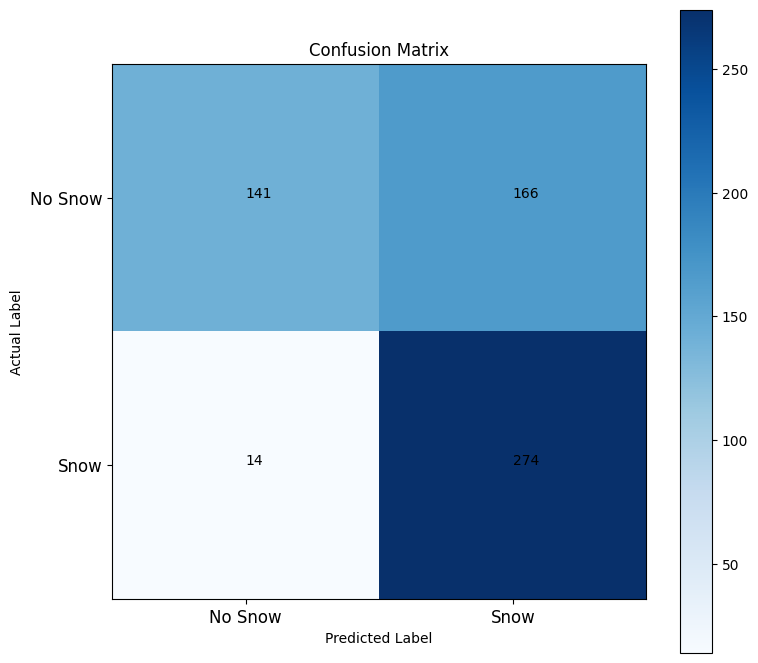

In [ ]:
#Confusion Matrix 

# Predict on test set
y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')

categories = ['No Snow', 'Snow']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticklabels(categories, fontsize=12)

for i in range(2): #for calculation
    for j in range(2):
        text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, cm[i, j])

ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


Another way to make sure that your model is performing well is to plot the Confusion Matrix.

*TASK:* Plot a confusion matrix for the model

After we made sure that our model is good, we export it.

In [ ]:
model.save("snow_forecast.keras")
model.export("snow_forecast")

INFO:tensorflow:Assets written to: snow_forecast/assets


INFO:tensorflow:Assets written to: snow_forecast/assets


Saved artifact at 'snow_forecast'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  4880123504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5177747312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5178221216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5178221920: TensorSpec(shape=(), dtype=tf.resource, name=None)


Here are the quantization settings. You might want to play with them to achieve different results.

Technical definition: Converting neural network weights and activations from 32-bit floating point numbers (float32) to 8-bit integers (int8).

In [85]:
#quantization

# Create calibration data
def representative_data_gen():
    data = tf.data.Dataset.from_tensor_slices(x_test)
    for i_value in data.batch(1).take(100):
        i_value_f32 = tf.dtypes.cast(i_value, tf.float32)
        yield [i_value_f32]

#  Create converter
converter = tf.lite.TFLiteConverter.from_saved_model("snow_forecast")

#  Configure quantization
converter.representative_dataset = tf.lite.RepresentativeDataset(representative_data_gen)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

#  Convert
tflite_model_quant = converter.convert()

#  Save
with open("snow_model.tflite", "wb") as f:
    f.write(tflite_model_quant)

print(f"Size: {len(tflite_model_quant) / 1024:.2f} KB")

Size: 2.40 KB


W0000 00:00:1773826081.650571 8156051 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773826081.650896 8156051 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1773826081.654196 8156051 reader.cc:83] Reading SavedModel from: snow_forecast
I0000 00:00:1773826081.654862 8156051 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1773826081.654866 8156051 reader.cc:147] Reading SavedModel debug info (if present) from: snow_forecast
I0000 00:00:1773826081.664821 8156051 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1773826081.714964 8156051 loader.cc:220] Running initialization op on SavedModel bundle at path: snow_forecast
I0000 00:00:1773826081.719925 8156051 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 65859 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1773826081.946292 8156051 flatbuffer_export.cc:3851] Ski

In [84]:
# Representative dataset
converter.representative_dataset = tf.lite.RepresentativeDataset(representative_data_gen)

# Optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Supported ops
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Inference input/output type
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

In [ ]:
def representative_data_gen():

  data = tf.data.Dataset.from_tensor_slices(x_test)

  for i_value in data.batch(1).take(100):
    i_value_f32 = tf.dtypes.cast(i_value, tf.float32)
    yield [i_value_f32]

We need to, however, quantize it to make it work on MCUs and to make it faster.

In [ ]:
TF_MODEL = "snow_forecast"
converter = tf.lite.TFLiteConverter.from_saved_model(TF_MODEL)

In [ ]:
tflite_model_quant = converter.convert()

W0000 00:00:1773770572.376814 8156051 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773770572.376841 8156051 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1773770572.377448 8156051 reader.cc:83] Reading SavedModel from: snow_forecast
I0000 00:00:1773770572.377956 8156051 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1773770572.377962 8156051 reader.cc:147] Reading SavedModel debug info (if present) from: snow_forecast
I0000 00:00:1773770572.380426 8156051 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1773770572.380839 8156051 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1773770572.395933 8156051 loader.cc:220] Running initialization op on SavedModel bundle at path: snow_forecast
I0000 00:00:1773770572.401410 8156051 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 23966 microseconds.
I0000 00:00:1773770572.459542 8156051 dump_mli

In [ ]:
#foк optimization: 
# • Stored in flash
# • Uses 0 KB of RAM
# • Aligned for fast access
# • Faster inference

import os

# Read the current model.h
with open("model.h", "r") as f:
    content = f.read()

# Add the modifications
content = content.replace("unsigned char", "const unsigned char")
content = content.replace("const unsigned", "alignas(8) const unsigned")

# Write back
with open("model.h", "w") as f:
    f.write(content)

After we finish with the conversion, we export the model as .tflite

In [ ]:
TFL_MODEL_FILE = "snow_model.tflite"
open(TFL_MODEL_FILE, "wb").write(tflite_model_quant)

2432